In [1]:
import pandas as pd 
import numpy as np
import re 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers 
from transformers import pipeline 

In [5]:
data = pd.read_csv('tripadvisor_hotel_reviews.csv')

In [6]:
data.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [7]:
data['Review'][0]

'nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  '

In [8]:
data['review_clean']=data['Review'].str.lower()

In [17]:
data['review_clean']= data.apply(lambda x : re.sub( r"([^\w\s])" , "", x['review_clean']) , axis=1)

In [19]:
data.head()

,Review,Rating,review_clean
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4 experience hotel monaco seatt...
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...


In [20]:
vader_sentiment= SentimentIntensityAnalyzer()

In [25]:
data['vader_sentiment_score'] = data['review_clean'].apply(lambda review : vader_sentiment.polarity_scores(review)['compound']) 

In [26]:
data.head()

,Review,Rating,review_clean,vader_sentiment_score
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,0.9626
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,0.9870
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4 experience hotel monaco seatt...,0.9921
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,0.9946
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,0.9907


In [28]:
bins = [-1 , -0.1 , 0.1 , 1]
names =['negative' , 'neutral' ,'positive'] 

In [31]:
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'] , bins , labels = names)
data.head()

,Review,Rating,review_clean,vader_sentiment_score,vader_sentiment_label
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,0.9626,positive
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,0.9870,positive
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4 experience hotel monaco seatt...,0.9921,positive
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,0.9946,positive
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,0.9907,positive


<Axes: title={'center': 'Vader sentiment analysis'}, xlabel='vader_sentiment_label'>

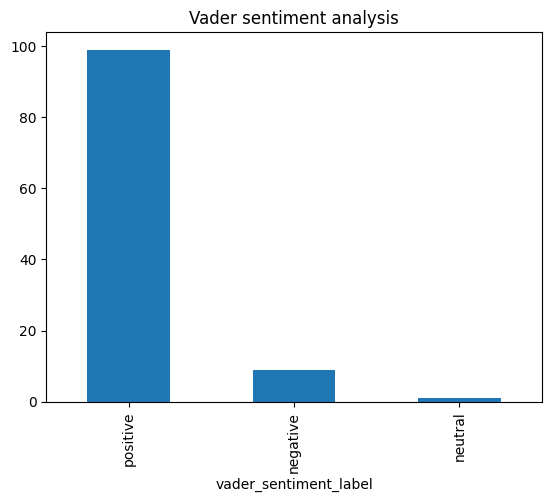

In [43]:
data['vader_sentiment_label'].value_counts().plot(kind="bar" , title="Vader sentiment analysis")

In [34]:
transformer_pipeline = pipeline ('sentiment-analysis')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [39]:
transformer_label=[]

for review in data['review_clean']:
    sentiment_list= transformer_pipeline(review)
    sentiment_label=[sent['label'] for sent in sentiment_list]
    transformer_label.append(sentiment_label)

data['tranformer_label'] = transformer_label
data.head()
    

,Review,Rating,review_clean,vader_sentiment_score,vader_sentiment_label,tranformer_label
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,0.9626,positive,[NEGATIVE]
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,0.9870,positive,[NEGATIVE]
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4 experience hotel monaco seatt...,0.9921,positive,[NEGATIVE]
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,0.9946,positive,[POSITIVE]
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,0.9907,positive,[NEGATIVE]


<Axes: title={'center': 'Transformer Sentiment Analysis'}, xlabel='tranformer_label'>

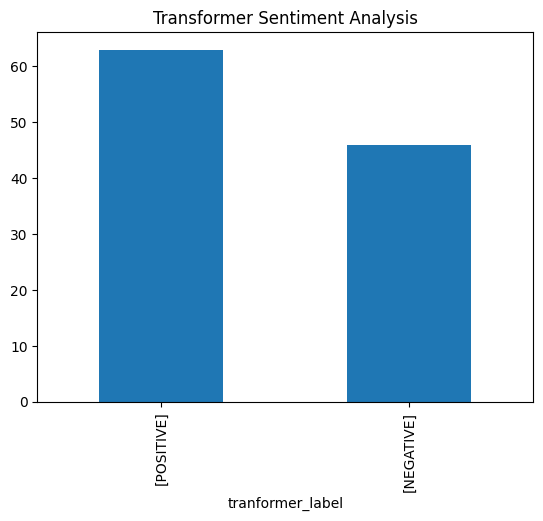

In [41]:
data['tranformer_label'].value_counts().plot(kind="bar" , title="Transformer Sentiment Analysis")